In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
edges = [(0, 1), (0, 2), (1, 2), (2, 0), (3, 2), (3, 0), (1, 3)]
n = 4

A = np.zeros((n, n))
for src, dst in edges:
    A[dst, src] = 1

print("Adjacency matrix A (A[dst, src] = 1):")
print(A)

Adjacency matrix A (A[dst, src] = 1):
[[0. 0. 1. 1.]
 [1. 0. 0. 0.]
 [1. 1. 0. 1.]
 [0. 1. 0. 0.]]


In [3]:
d = 0.85

out_degree = A.sum(axis=0)
out_degree[out_degree == 0] = 1
M = A / out_degree

P = d * M + (1 - d) / n * np.ones((n, n))

print("Markov (transition) matrix P:")
print(np.round(P, 3))
print("Column sums (should be 1):", P.sum(axis=0).round(3))

Markov (transition) matrix P:
[[0.038 0.038 0.888 0.462]
 [0.462 0.038 0.038 0.038]
 [0.462 0.462 0.038 0.462]
 [0.038 0.462 0.038 0.038]]
Column sums (should be 1): [1. 1. 1. 1.]


In [4]:
def power_iter_normalized(P, steps=100):
    r = np.ones(len(P)) / len(P)
    history = [r.copy()]
    for _ in range(steps):
        r = P @ r
        r = r / r.sum()
        history.append(r.copy())
    return r, np.array(history)

def power_iter_unnormalized(P, steps=100):
    r = np.ones(len(P)) / len(P)
    history = [r.copy()]
    for _ in range(steps):
        r = P @ r
        history.append(r.copy())
    return r, np.array(history)

In [5]:
ranks_norm, hist_norm = power_iter_normalized(P)
ranks_unnorm, hist_unnorm = power_iter_unnormalized(P)

print("PageRank (with normalization):   ", ranks_norm.round(4))
print("PageRank (without normalization):", ranks_unnorm.round(4))

PageRank (with normalization):    [0.364  0.1922 0.3246 0.1192]
PageRank (without normalization): [0.364  0.1922 0.3246 0.1192]


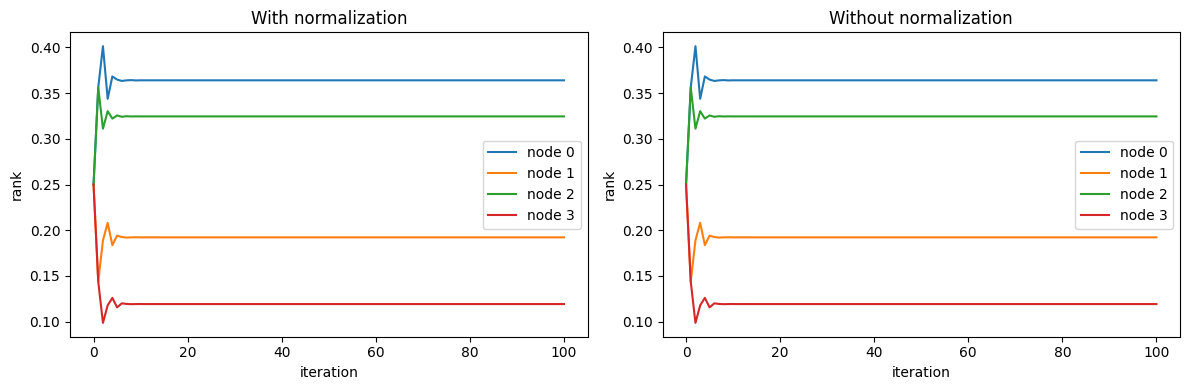

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [f"node {i}" for i in range(n)]

for i in range(n):
    axes[0].plot(hist_norm[:, i], label=labels[i])
axes[0].set_title("With normalization")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("rank")
axes[0].legend()

for i in range(n):
    axes[1].plot(hist_unnorm[:, i], label=labels[i])
axes[1].set_title("Without normalization")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("rank")
axes[1].legend()

plt.tight_layout()
plt.show()

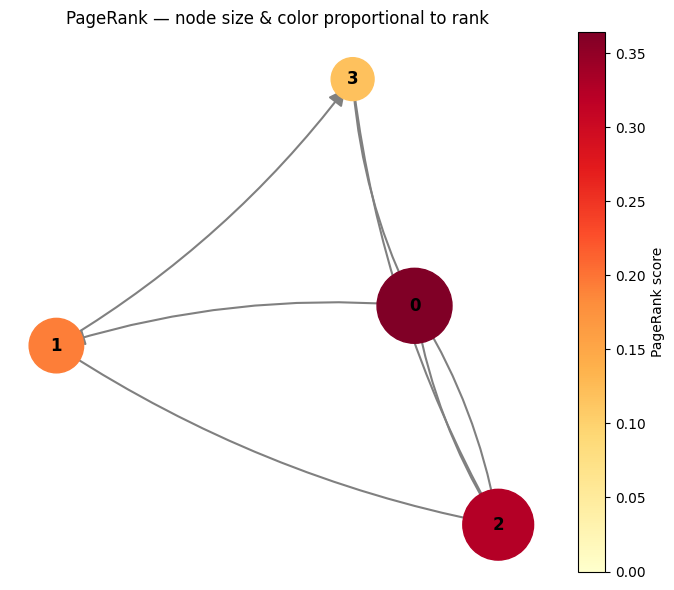

In [7]:
G = nx.DiGraph()
G.add_nodes_from(range(n))
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)
sizes = ranks_norm * 8000
colors = ranks_norm

fig, ax = plt.subplots(figsize=(7, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=25,
                       edge_color='gray', width=1.5, connectionstyle='arc3,rad=0.1')
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors,
                             cmap='YlOrRd', vmin=0, vmax=max(colors))
nx.draw_networkx_labels(G, pos, ax=ax, font_color='black', font_weight='bold')
plt.colorbar(nc, ax=ax, label='PageRank score')
ax.set_title("PageRank — node size & color proportional to rank")
ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
def random_graph_pagerank(n_nodes, n_edges, d=0.85, seed=42):
    rng = np.random.default_rng(seed)
    src = rng.integers(0, n_nodes, size=n_edges)
    dst = rng.integers(0, n_nodes, size=n_edges)
    edges_rand = list(set(zip(src.tolist(), dst.tolist())))

    A = np.zeros((n_nodes, n_nodes))
    for s, t in edges_rand:
        A[t, s] = 1

    out_deg = A.sum(axis=0)
    out_deg[out_deg == 0] = 1
    M = A / out_deg
    P = d * M + (1 - d) / n_nodes * np.ones((n_nodes, n_nodes))

    ranks, _ = power_iter_normalized(P)
    return edges_rand, ranks

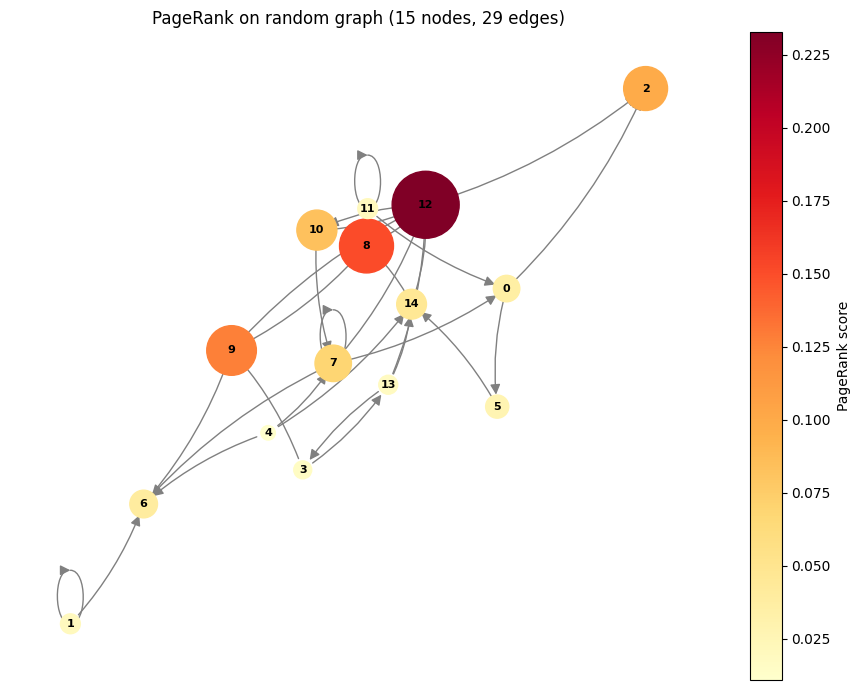

Top-5 nodes: [12  8  9  2 10] | ranks: [0.2327 0.1509 0.1277 0.0999 0.083 ]


In [9]:
N, E = 15, 30
rand_edges, rand_ranks = random_graph_pagerank(N, E, seed=7)

G_rand = nx.DiGraph()
G_rand.add_nodes_from(range(N))
G_rand.add_edges_from(rand_edges)

pos_rand = nx.spring_layout(G_rand, seed=7)
sizes_rand = rand_ranks * 10000

fig, ax = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(G_rand, pos_rand, ax=ax, arrows=True, arrowsize=15,
                       edge_color='gray', width=1.0, connectionstyle='arc3,rad=0.1')
nc2 = nx.draw_networkx_nodes(G_rand, pos_rand, ax=ax, node_size=sizes_rand,
                              node_color=rand_ranks, cmap='YlOrRd')
nx.draw_networkx_labels(G_rand, pos_rand, ax=ax, font_size=8, font_weight='bold')
plt.colorbar(nc2, ax=ax, label='PageRank score')
ax.set_title(f"PageRank on random graph ({N} nodes, {len(rand_edges)} edges)")
ax.axis('off')
plt.tight_layout()
plt.show()

top5 = np.argsort(rand_ranks)[::-1][:5]
print("Top-5 nodes:", top5, "| ranks:", rand_ranks[top5].round(4))